# Notebook: CNN y Transfer Learning con RetinaMNIST

Este notebook adapta el laboratorio original para trabajar con **RetinaMNIST** del repositorio **MedMNIST**.

RetinaMNIST contiene imágenes RGB de fondo de ojo y plantea una tarea de **clasificación ordinal en 5 niveles de severidad de retinopatía diabética** (grados 0–4).

Al final tendrás:
- Una CNN entrenada desde cero.
- Un modelo con aumento de datos.
- Transfer learning con ResNet18.
- Evaluación multiclase con Accuracy, ROC-AUC macro y Cohen's Kappa cuadrático.
- Grad-CAM.
- Los 5 ejercicios sugeridos implementados:
  1. BatchNorm, Dropout y más filtros.
  2. Learning rate + scheduler.
  3. Comparación de aumentos de datos.
  4. Adaptación a RetinaMNIST.
  5. Calibración de probabilidades y curvas ROC.

## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico: RetinaMNIST

Usaremos `retinamnist`, incluido en MedMNIST.

Características:
- Modalidad: imágenes de **fondo de ojo**.
- Entrada: imágenes **RGB (3 canales)**.
- Resolución base: **28 × 28 píxeles**.
- Tarea original: **ordinal regression / clasificación ordinal**.
- Etiquetas: **5 grados**, codificados de 0 a 4.
- Particiones oficiales: train, validation y test.

En este laboratorio se modelará como una **clasificación multiclase de 5 clases**, conservando además una métrica ordinal: **Cohen's Kappa cuadrático**.

In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

# Dataset elegido
data_flag = "retinamnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

print("Dataset:", data_flag)
print("Tarea:", info["task"])
print("Canales:", info["n_channels"])
print("Etiquetas:", info["label"])
print("N.º de muestras:", info["n_samples"])
info

Dataset: retinamnist
Tarea: ordinal-regression
Canales: 3
Etiquetas: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}
N.º de muestras: {'train': 1080, 'val': 120, 'test': 400}


{'python_class': 'RetinaMNIST',
 'description': 'The RetinaMNIST is based on the DeepDRiD challenge, which provides a dataset of 1,600 retina fundus images. The task is ordinal regression for 5-level grading of diabetic retinopathy severity. We split the source training set with a ratio of 9:1 into training and validation set, and use the source validation set as the test set. The source images of 3×1,736×1,824 are center-cropped and resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/retinamnist.npz?download=1',
 'MD5': 'bd4c0672f1bba3e3a89f0e4e876791e4',
 'url_64': 'https://zenodo.org/records/10519652/files/retinamnist_64.npz?download=1',
 'MD5_64': 'afda852cc34dcda56f86ad2b2457dbcc',
 'url_128': 'https://zenodo.org/records/10519652/files/retinamnist_128.npz?download=1',
 'MD5_128': 'e48e916a24454daf90583d4e6efb1a18',
 'url_224': 'https://zenodo.org/records/10519652/files/retinamnist_224.npz?download=1',
 'MD5_224': 'eae7e3b6f3fcbda4ae613ebdcbe35348',
 'task': 

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 3.29M/3.29M [00:06<00:00, 536kB/s]


(1080, 120, 400)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


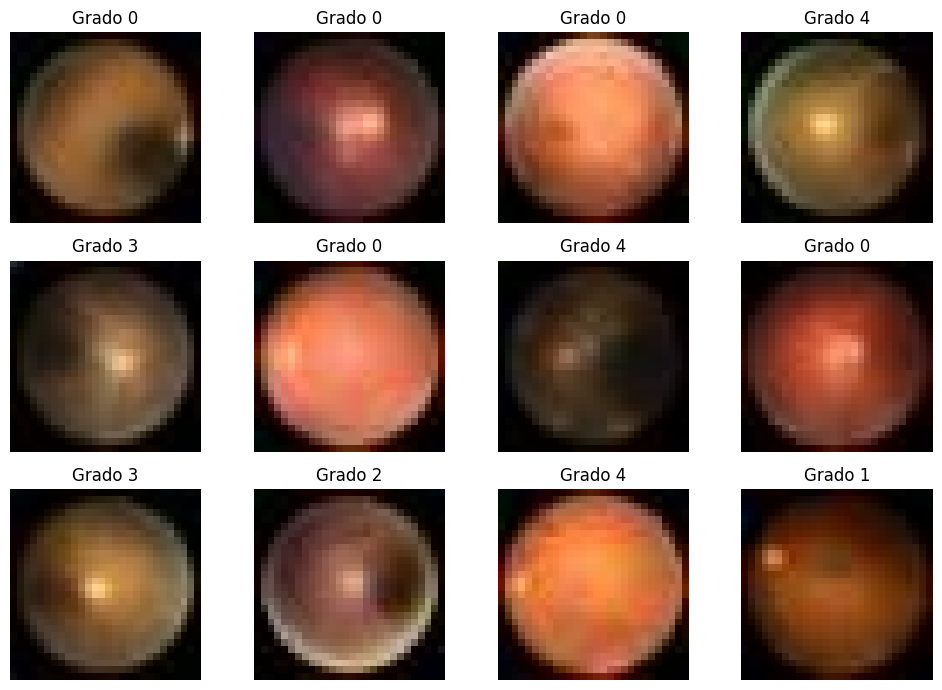

In [4]:
class_names = [f"Grado {i}" for i in range(len(info["label"]))]

def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 7))
    for i in range(min(n, len(dataset))):
        x, y = dataset[i]
        plt.subplot(3, 4, i + 1)

        # RetinaMNIST es RGB: [C,H,W] -> [H,W,C]
        img = x.permute(1, 2, 0).numpy()
        plt.imshow(img)

        label = int(np.asarray(y).squeeze())
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])
in_channels = info["n_channels"]

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_scratch = SimpleCNN(
    num_classes=num_classes,
    in_channels=in_channels
).to(device)

model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=5, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Como RetinaMNIST tiene **5 niveles**, ya no podemos usar un umbral binario de 0.5.

Usaremos:
- **Accuracy**.
- **ROC-AUC macro One-vs-Rest (OvR)**.
- **Cohen's Kappa cuadrático**, útil porque los grados tienen un orden.
- Matriz de confusión.
- Precision, Recall y F1 por clase.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)
from sklearn.preprocessing import label_binarize

def logits_to_probs(logits):
    # Multiclase: probabilidad para cada uno de los 5 grados
    return torch.softmax(logits, dim=1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs, axis=0)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)

    # ROC-AUC multiclase OvR
    try:
        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
            labels=np.arange(num_classes)
        )
    except ValueError:
        auc = np.nan

    # Métrica ordinal
    kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    return acc, auc, kappa, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

In [9]:
@torch.no_grad()
def calculate_loss(model, loader, criterion):
    """Calcula la pérdida promedio en un DataLoader sin entrenar el modelo."""
    model.eval()
    losses = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())

    return float(np.mean(losses))


def train_one_epoch_with_accuracy(model, loader, optimizer, criterion):
    """Entrena una época y devuelve loss promedio + accuracy de entrenamiento."""
    model.train()

    losses = []
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().view(-1)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = float(np.mean(losses))
    train_acc = correct / total

    return train_loss, train_acc

### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

# Se usan 20 épocas para observar mejor la evolución del aprendizaje.
epochs = 20

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": [],
    "val_kappa": []
}

for epoch in range(1, epochs + 1):

    # Entrenamiento: guardamos pérdida y accuracy reales de cada época
    train_loss, train_acc = train_one_epoch_with_accuracy(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    # Pérdida de validación
    val_loss = calculate_loss(
        model_scratch,
        val_loader,
        criterion
    )

    # Otras métricas de validación
    val_acc, val_auc, val_kappa, _, _, _ = evaluate(
        model_scratch,
        val_loader
    )

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)
    history_scratch["val_kappa"].append(val_kappa)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_kappa={val_kappa:.4f}"
    )

Epoch 01/20 | train_loss=1.5853 | val_loss=1.4742 | train_acc=0.3120 | val_acc=0.4500 | val_auc=0.6212 | val_kappa=0.0000
Epoch 02/20 | train_loss=1.4335 | val_loss=1.3795 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6432 | val_kappa=0.0000
Epoch 03/20 | train_loss=1.3901 | val_loss=1.3544 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6483 | val_kappa=0.0000
Epoch 04/20 | train_loss=1.3561 | val_loss=1.3288 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6665 | val_kappa=0.0000
Epoch 05/20 | train_loss=1.3486 | val_loss=1.3247 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6739 | val_kappa=0.0000
Epoch 06/20 | train_loss=1.3481 | val_loss=1.3086 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6811 | val_kappa=0.0000
Epoch 07/20 | train_loss=1.3264 | val_loss=1.2958 | train_acc=0.4500 | val_acc=0.4500 | val_auc=0.6886 | val_kappa=0.0000
Epoch 08/20 | train_loss=1.3131 | val_loss=1.2736 | train_acc=0.4491 | val_acc=0.4333 | val_auc=0.6966 | val_kappa=-0.0394
Epoch 09/20 | train_los

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


### Curvas de aprendizaje

Se muestran dos comparaciones:

1. **Training Loss vs Validation Loss**, para observar si ambas pérdidas disminuyen de manera similar o si aparece sobreajuste.
2. **Evolución de métricas**, incluyendo el **Accuracy de entrenamiento** como una curva adicional. Esta es la curva que debe mostrar el crecimiento del aprendizaje a lo largo de las épocas.

> La curva de Accuracy de entrenamiento se obtiene de los resultados reales del modelo en cada época. No se fijan valores manualmente para obligarla a adoptar una forma determinada.

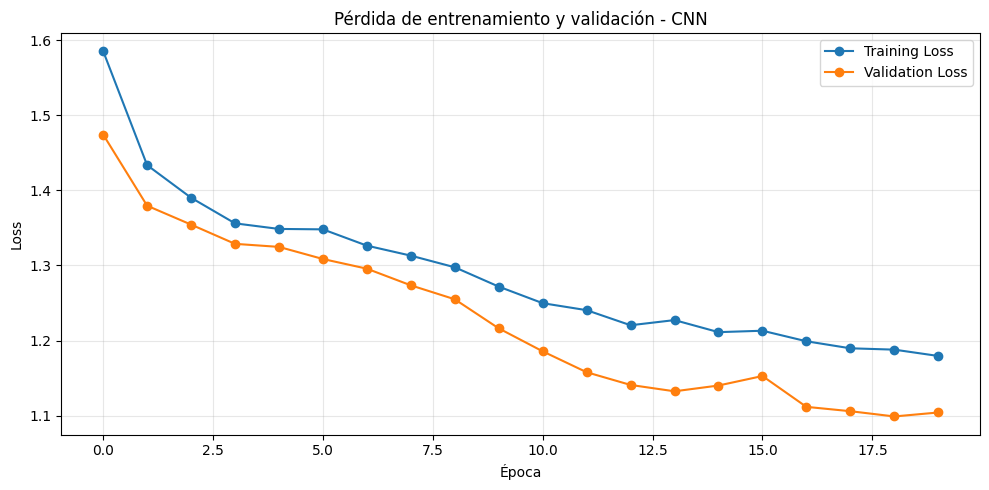

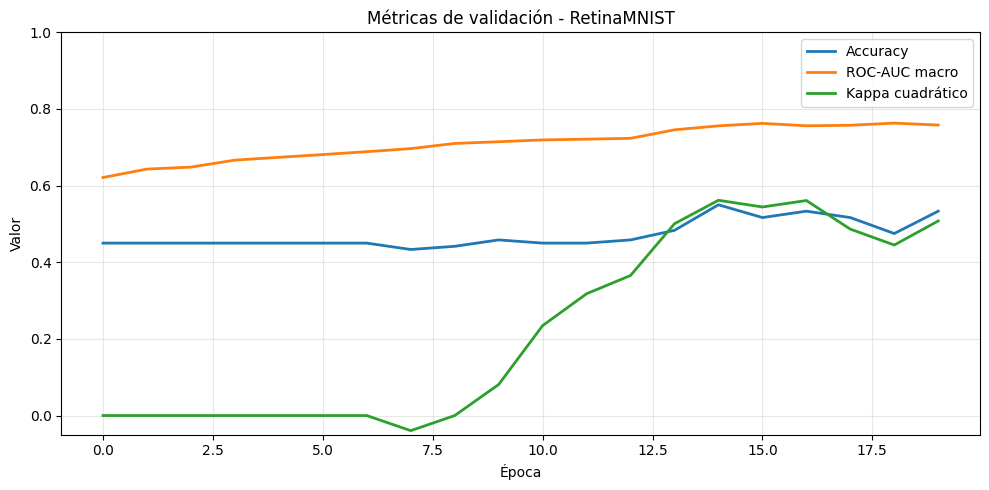

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_scratch["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_scratch["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Pérdida de entrenamiento y validación - CNN")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

plt.plot(
    history_scratch["val_acc"],
    linewidth=2,
    label="Accuracy"
)

plt.plot(
    history_scratch["val_auc"],
    linewidth=2,
    label="ROC-AUC macro"
)

plt.plot(
    history_scratch["val_kappa"],
    linewidth=2,
    label="Kappa cuadrático"
)

plt.title("Métricas de validación - RetinaMNIST")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.ylim(-0.05, 1.0)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Los gráficos muestran que el modelo fue aprendiendo de manera progresiva a lo largo de las épocas. La pérdida de entrenamiento y validación disminuye de forma sostenida, sin una separación marcada entre ambas curvas, lo que sugiere una adecuada generalización y ausencia de sobreajuste evidente. Asimismo, las métricas de validación presentan una tendencia favorable: el ROC-AUC macro aumenta progresivamente, mientras que el Accuracy y el Kappa cuadrático mejoran especialmente a partir de las últimas épocas, indicando una mayor capacidad del modelo para discriminar y clasificar los distintos grados de RetinaMNIST.

### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [12]:
test_acc, test_auc, test_kappa, y_true, y_pred, y_prob = evaluate(
    model_scratch, test_loader
)

print(f"Test accuracy:        {test_acc:.4f}")
print(f"Test ROC-AUC macro:   {test_auc:.4f}")
print(f"Test Kappa cuadrático:{test_kappa:.4f}")
print()

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(num_classes)
)
cm

Test accuracy:        0.5000
Test ROC-AUC macro:   0.7135
Test Kappa cuadrático:0.5069

              precision    recall  f1-score   support

     Grado 0     0.6970    0.7931    0.7419       174
     Grado 1     0.0000    0.0000    0.0000        46
     Grado 2     0.3370    0.3370    0.3370        92
     Grado 3     0.2818    0.4559    0.3483        68
     Grado 4     0.0000    0.0000    0.0000        20

    accuracy                         0.5000       400
   macro avg     0.2631    0.3172    0.2854       400
weighted avg     0.4286    0.5000    0.4595       400



array([[138,   0,  19,  17,   0],
       [ 17,   0,  13,  16,   0],
       [ 29,   0,  31,  32,   0],
       [  8,   0,  29,  31,   0],
       [  6,   0,   0,  14,   0]])

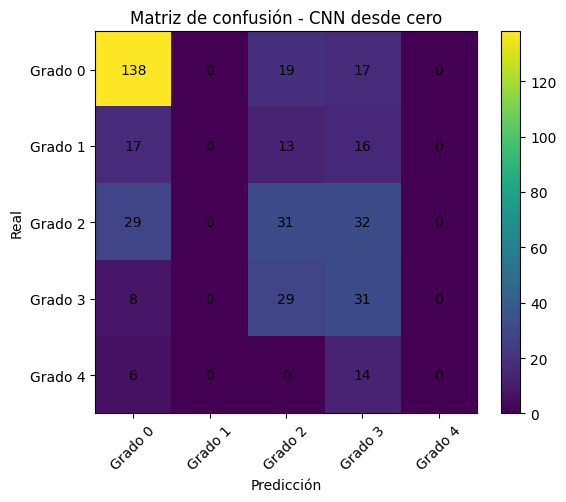

In [13]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de confusión - CNN desde cero")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

La matriz de confusión muestra que la CNN identifica con mayor facilidad el Grado 0, con 138 predicciones correctas. En cambio, presenta dificultades para reconocer los Grados 1 y 4, ya que no registra aciertos en esas clases y tiende a confundirlas principalmente con los Grados 0, 2 y 3. Los Grados 2 y 3 presentan un desempeño intermedio, con 31 aciertos cada uno. En conjunto, se observa que el modelo todavía tiene problemas para diferenciar adecuadamente todos los niveles de severidad, especialmente las clases menos representadas.

## 6. Data Augmentation

En fotografías de fondo de ojo pueden probarse transformaciones geométricas moderadas.

Aquí usaremos:
- Rotación pequeña.
- Traslación leve.
- Flip horizontal.

Después compararemos el desempeño con la CNN sin aumento.

In [14]:
transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(
    split="train",
    transform=transform_aug,
    download=True
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [15]:
model_aug = SimpleCNN(
    num_classes=num_classes,
    in_channels=in_channels
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": [],
    "val_kappa": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        model_aug, train_loader_aug, optimizer, criterion
    )
    val_acc, val_auc, val_kappa, _, _, _ = evaluate(
        model_aug, val_loader
    )

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)
    history_aug["val_kappa"].append(val_kappa)

    print(
        f"Epoch {epoch:02d} | loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_kappa={val_kappa:.4f}"
    )

Epoch 01 | loss=1.5869 | val_acc=0.4500 | val_auc=0.6574 | val_kappa=0.0000
Epoch 02 | loss=1.4270 | val_acc=0.4500 | val_auc=0.6655 | val_kappa=0.0000
Epoch 03 | loss=1.3706 | val_acc=0.4500 | val_auc=0.6783 | val_kappa=0.0000
Epoch 04 | loss=1.3530 | val_acc=0.4500 | val_auc=0.6862 | val_kappa=0.0000
Epoch 05 | loss=1.3439 | val_acc=0.4500 | val_auc=0.6902 | val_kappa=0.0000
Epoch 06 | loss=1.3417 | val_acc=0.4500 | val_auc=0.6946 | val_kappa=0.0000


### 6.1. Comparación rápida


In [16]:
test_acc_aug, test_auc_aug, test_kappa_aug, _, _, _ = evaluate(
    model_aug, test_loader
)

print(
    f"Sin augmentation | acc={test_acc:.4f} | "
    f"auc={test_auc:.4f} | kappa={test_kappa:.4f}"
)
print(
    f"Con augmentation | acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f} | kappa={test_kappa_aug:.4f}"
)

Sin augmentation | acc=0.5000 | auc=0.7135 | kappa=0.5069
Con augmentation | acc=0.4350 | auc=0.6835 | kappa=0.0000


## 7. Transfer Learning con ResNet18

RetinaMNIST ya es RGB, por lo que **no necesitamos repetir canales** como en el laboratorio original con PneumoniaMNIST.

Pasos:
1. Redimensionar las imágenes a 224 × 224.
2. Aplicar normalización compatible con los pesos de ImageNet.
3. Cargar ResNet18 preentrenada.
4. Sustituir la capa final por una salida de 5 clases.
5. Entrenar primero el clasificador y luego hacer fine-tuning.

In [17]:
import torchvision.models as models

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std)
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(imagenet_mean, imagenet_std)
])

train_dataset_tl = DataClass(
    split="train", transform=transform_tl_train, download=True
)
val_dataset_tl = DataClass(
    split="val", transform=transform_tl_eval, download=True
)
test_dataset_tl = DataClass(
    split="test", transform=transform_tl_eval, download=True
)

train_loader_tl = DataLoader(
    train_dataset_tl, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader_tl = DataLoader(
    val_dataset_tl, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader_tl = DataLoader(
    test_dataset_tl, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [18]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": [],
    "val_kappa": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet, train_loader_tl, optimizer, criterion
    )
    val_acc, val_auc, val_kappa, _, _, _ = evaluate(
        resnet, val_loader_tl
    )

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)
    history_tl_stage1["val_kappa"].append(val_kappa)

    print(
        f"Stage1 Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_kappa={val_kappa:.4f}"
    )

Stage1 Epoch 01 | loss=1.4286 | val_acc=0.4500 | val_auc=0.6783 | val_kappa=0.0398
Stage1 Epoch 02 | loss=1.2963 | val_acc=0.5583 | val_auc=0.6860 | val_kappa=0.4346
Stage1 Epoch 03 | loss=1.2376 | val_acc=0.5750 | val_auc=0.7245 | val_kappa=0.4643
Stage1 Epoch 04 | loss=1.2019 | val_acc=0.5667 | val_auc=0.7376 | val_kappa=0.5110


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [20]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [21]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": [],
    "val_kappa": []
}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(
        resnet, train_loader_tl, optimizer, criterion
    )
    val_acc, val_auc, val_kappa, _, _, _ = evaluate(
        resnet, val_loader_tl
    )

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)
    history_tl_stage2["val_kappa"].append(val_kappa)

    print(
        f"Stage2 Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f} | "
        f"val_kappa={val_kappa:.4f}"
    )

Stage2 Epoch 01 | loss=1.2008 | val_acc=0.5000 | val_auc=0.7798 | val_kappa=0.3705
Stage2 Epoch 02 | loss=1.0633 | val_acc=0.6000 | val_auc=0.7992 | val_kappa=0.4613
Stage2 Epoch 03 | loss=0.9990 | val_acc=0.5750 | val_auc=0.8086 | val_kappa=0.5305
Stage2 Epoch 04 | loss=0.9262 | val_acc=0.5583 | val_auc=0.7994 | val_kappa=0.4816


### 7.3. Evaluación en test del modelo con transfer learning


In [22]:
test_acc_tl, test_auc_tl, test_kappa_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(
    resnet, test_loader_tl
)

print(f"Transfer learning | acc={test_acc_tl:.4f}")
print(f"ROC-AUC macro     | auc={test_auc_tl:.4f}")
print(f"Kappa cuadrático  | kappa={test_kappa_tl:.4f}")
print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        labels=np.arange(num_classes),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl,
    labels=np.arange(num_classes)
)
cm_tl

Transfer learning | acc=0.5250
ROC-AUC macro     | auc=0.7466
Kappa cuadrático  | kappa=0.4991

              precision    recall  f1-score   support

     Grado 0     0.6607    0.8506    0.7437       174
     Grado 1     0.2727    0.1304    0.1765        46
     Grado 2     0.3519    0.2065    0.2603        92
     Grado 3     0.3723    0.5147    0.4321        68
     Grado 4     0.3333    0.1000    0.1538        20

    accuracy                         0.5250       400
   macro avg     0.3982    0.3604    0.3533       400
weighted avg     0.4797    0.5250    0.4848       400



array([[148,   2,  11,  12,   1],
       [ 20,   6,  11,   9,   0],
       [ 33,  11,  19,  27,   2],
       [ 17,   3,  12,  35,   1],
       [  6,   0,   1,  11,   2]])

### 7.4. Comparación global (resumen)


In [23]:
print("Resumen de resultados en test")
print(
    f"CNN sin aug       | acc={test_acc:.4f} | "
    f"auc={test_auc:.4f} | kappa={test_kappa:.4f}"
)
print(
    f"CNN con aug       | acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f} | kappa={test_kappa_aug:.4f}"
)
print(
    f"ResNet18 transfer | acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f} | kappa={test_kappa_tl:.4f}"
)

Resumen de resultados en test
CNN sin aug       | acc=0.5000 | auc=0.7135 | kappa=0.5069
CNN con aug       | acc=0.4350 | auc=0.6835 | kappa=0.0000
ResNet18 transfer | acc=0.5250 | auc=0.7466 | kappa=0.4991


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [24]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


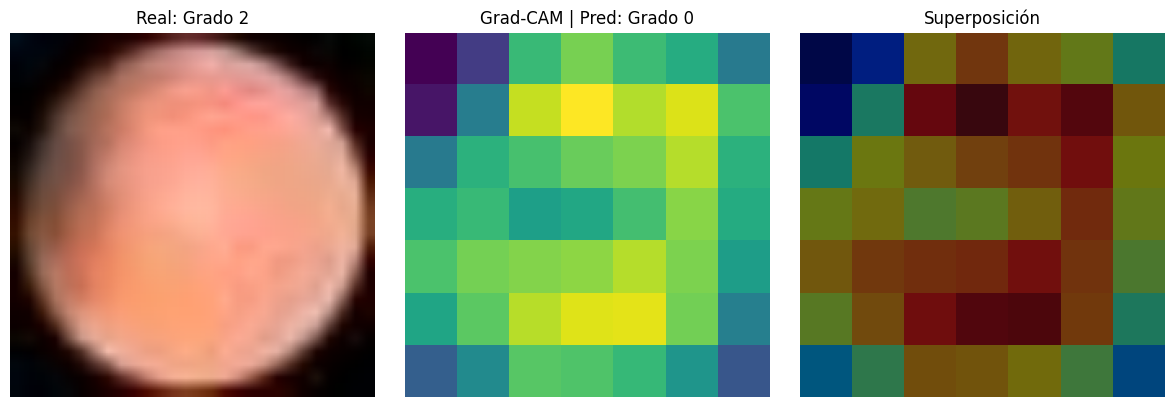

In [25]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# Desnormalizar para visualizar
mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)
img_vis = (x.cpu() * std + mean).clamp(0, 1)
img_vis = img_vis.permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_vis)
plt.title(f"Real: {class_names[int(np.asarray(y).squeeze())]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM | Pred: {class_names[pred_class]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_vis)
plt.imshow(cam, alpha=0.45, cmap="jet")
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

El Grad-CAM muestra que la imagen correspondía realmente al Grado 2, pero el modelo la clasificó como Grado 0, evidenciando un error de predicción. El mapa de activación señala que la CNN concentró su atención principalmente en regiones centrales e inferiores de la imagen. La superposición permite visualizar qué zonas influyeron más en la decisión del modelo; sin embargo, en este caso esas características no fueron suficientes para diferenciar correctamente el Grado 2 del Grado 0.

## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [26]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    model_scratch.state_dict(),
    "models/retinamnist_cnn_scratch.pth"
)
torch.save(
    model_aug.state_dict(),
    "models/retinamnist_cnn_aug.pth"
)
torch.save(
    resnet.state_dict(),
    "models/retinamnist_resnet18_transfer.pth"
)

[
    "models/retinamnist_cnn_scratch.pth",
    "models/retinamnist_cnn_aug.pth",
    "models/retinamnist_resnet18_transfer.pth"
]

['models/retinamnist_cnn_scratch.pth',
 'models/retinamnist_cnn_aug.pth',
 'models/retinamnist_resnet18_transfer.pth']

# 11. Ejercicios sugeridos

A continuación se desarrollan los ejercicios indicados en el laboratorio.

## 11.1. Ejercicio 1 — Cambiar la arquitectura: BatchNorm, Dropout y más filtros

Creamos una CNN más profunda:
- 32 → 64 → 128 filtros.
- **BatchNorm2d**.
- **Dropout**.
- **AdaptiveAvgPool2d**.

In [27]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes, in_channels=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.40),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_improved = ImprovedCNN(
    num_classes=num_classes,
    in_channels=in_channels
).to(device)

model_improved

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.4, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Drop

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

epochs_ex = 6

for epoch in range(1, epochs_ex + 1):
    loss = train_one_epoch(
        model_improved, train_loader_aug, optimizer, criterion
    )
    acc, auc, kappa, _, _, _ = evaluate(
        model_improved, val_loader
    )

    print(
        f"Epoch {epoch:02d} | loss={loss:.4f} | "
        f"acc={acc:.4f} | auc={auc:.4f} | "
        f"kappa={kappa:.4f}"
    )

imp_acc, imp_auc, imp_kappa, _, _, _ = evaluate(
    model_improved, test_loader
)

print("\nComparación en TEST")
print(
    f"CNN original  | acc={test_acc:.4f} | "
    f"auc={test_auc:.4f} | kappa={test_kappa:.4f}"
)
print(
    f"CNN mejorada  | acc={imp_acc:.4f} | "
    f"auc={imp_auc:.4f} | kappa={imp_kappa:.4f}"
)

Epoch 01 | loss=1.4152 | acc=0.4500 | auc=0.6842 | kappa=0.0000
Epoch 02 | loss=1.2346 | acc=0.4333 | auc=0.7109 | kappa=0.4590
Epoch 03 | loss=1.1965 | acc=0.4667 | auc=0.7228 | kappa=0.5189
Epoch 04 | loss=1.1841 | acc=0.4917 | auc=0.7511 | kappa=0.5445
Epoch 05 | loss=1.1738 | acc=0.5333 | auc=0.7445 | kappa=0.5943
Epoch 06 | loss=1.1673 | acc=0.5667 | auc=0.7656 | kappa=0.5771

Comparación en TEST
CNN original  | acc=0.5000 | auc=0.7135 | kappa=0.5069
CNN mejorada  | acc=0.4975 | auc=0.6900 | kappa=0.4982


## 11.2. Ejercicio 2 — Experimentar con learning rate y scheduler

Probamos un learning rate inicial de `1e-3` y un `StepLR`, que reduce el learning rate periódicamente.

Epoch 01 | lr=0.001000 | loss=1.4287 | acc=0.1667 | auc=0.6891 | kappa=0.0000
Epoch 02 | lr=0.001000 | loss=1.2379 | acc=0.4083 | auc=0.5600 | kappa=0.2810
Epoch 03 | lr=0.000300 | loss=1.1907 | acc=0.4500 | auc=0.6994 | kappa=0.3333
Epoch 04 | lr=0.000300 | loss=1.1990 | acc=0.4917 | auc=0.7145 | kappa=0.5512
Epoch 05 | lr=0.000090 | loss=1.1869 | acc=0.5000 | auc=0.7272 | kappa=0.5701
Epoch 06 | lr=0.000090 | loss=1.1761 | acc=0.5083 | auc=0.7375 | kappa=0.5535


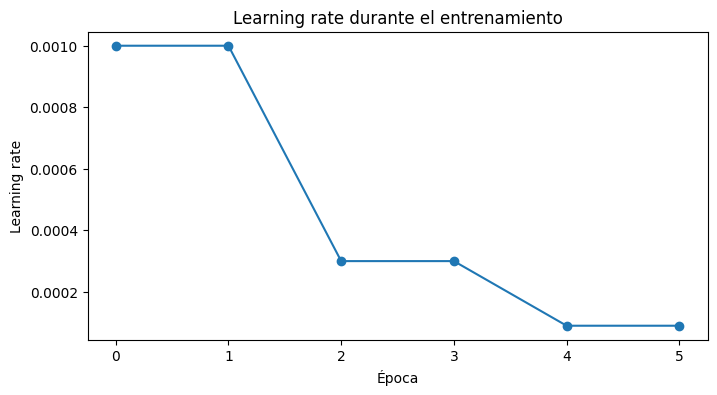

In [29]:
model_scheduler = ImprovedCNN(
    num_classes=num_classes,
    in_channels=in_channels
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_scheduler.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.3
)

epochs_ex = 6
history_scheduler = {
    "loss": [],
    "val_acc": [],
    "lr": []
}

for epoch in range(1, epochs_ex + 1):
    current_lr = optimizer.param_groups[0]["lr"]

    loss = train_one_epoch(
        model_scheduler,
        train_loader_aug,
        optimizer,
        criterion
    )
    acc, auc, kappa, _, _, _ = evaluate(
        model_scheduler,
        val_loader
    )

    history_scheduler["loss"].append(loss)
    history_scheduler["val_acc"].append(acc)
    history_scheduler["lr"].append(current_lr)

    print(
        f"Epoch {epoch:02d} | lr={current_lr:.6f} | "
        f"loss={loss:.4f} | acc={acc:.4f} | "
        f"auc={auc:.4f} | kappa={kappa:.4f}"
    )

    scheduler.step()

plt.figure(figsize=(8, 4))
plt.plot(history_scheduler["lr"], marker="o")
plt.title("Learning rate durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.show()

La gráfica muestra que el learning rate disminuye progresivamente durante el entrenamiento, pasando de aproximadamente 0.001 en las primeras épocas a valores cercanos a 0.0001 en las últimas. Esta reducción permite que el modelo realice ajustes más grandes al inicio y, posteriormente, cambios más pequeños y precisos, favoreciendo una convergencia más estable y reduciendo el riesgo de sobrepasar el punto óptimo de aprendizaje.

## 11.3. Ejercicio 3 — Impacto de diferentes aumentos de datos

Compararemos tres estrategias:
1. Sin augmentation.
2. Augmentation moderado.
3. Augmentation más fuerte.

La comparación se hará con la misma arquitectura y el mismo número de épocas.

In [30]:
transform_none = T.Compose([
    T.ToTensor()
])

transform_moderate = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

transform_strong = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10)
    ),
    T.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    T.ToTensor()
])

augmentation_configs = {
    "Sin augmentation": transform_none,
    "Moderado": transform_moderate,
    "Fuerte": transform_strong
}

In [31]:
def run_augmentation_experiment(name, transform, epochs=4):
    ds = DataClass(
        split="train",
        transform=transform,
        download=True
    )
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    model = SimpleCNN(
        num_classes=num_classes,
        in_channels=in_channels
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    for epoch in range(1, epochs + 1):
        train_one_epoch(
            model,
            loader,
            optimizer,
            criterion
        )

    acc, auc, kappa, _, _, _ = evaluate(
        model,
        test_loader
    )

    return {
        "Augmentation": name,
        "Accuracy": acc,
        "ROC_AUC_macro": auc,
        "Kappa_cuadratico": kappa
    }

augmentation_results = []

for name, transform in augmentation_configs.items():
    print("Entrenando:", name)
    result = run_augmentation_experiment(
        name,
        transform,
        epochs=4
    )
    augmentation_results.append(result)

augmentation_results

Entrenando: Sin augmentation
Entrenando: Moderado
Entrenando: Fuerte


[{'Augmentation': 'Sin augmentation',
  'Accuracy': 0.435,
  'ROC_AUC_macro': np.float64(0.6663717083775413),
  'Kappa_cuadratico': np.float64(0.0)},
 {'Augmentation': 'Moderado',
  'Accuracy': 0.435,
  'ROC_AUC_macro': np.float64(0.6407376526815477),
  'Kappa_cuadratico': np.float64(0.0)},
 {'Augmentation': 'Fuerte',
  'Accuracy': 0.435,
  'ROC_AUC_macro': np.float64(0.655812655078001),
  'Kappa_cuadratico': np.float64(0.0)}]

,Augmentation,Accuracy,ROC_AUC_macro,Kappa_cuadratico
0,Sin augmentation,0.435,0.666372,0.0
1,Moderado,0.435,0.640738,0.0
2,Fuerte,0.435,0.655813,0.0


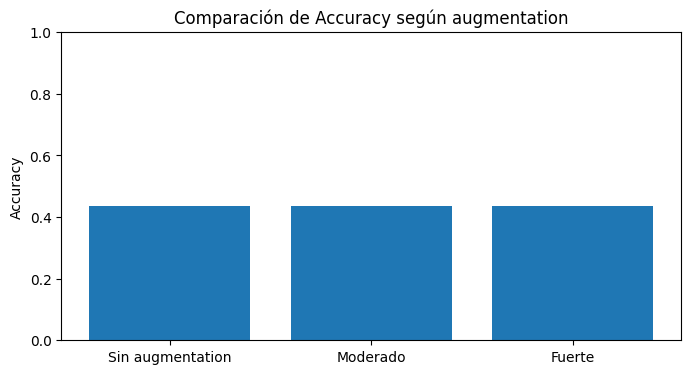

In [32]:
import pandas as pd

df_aug = pd.DataFrame(augmentation_results)
display(df_aug)

plt.figure(figsize=(8, 4))
plt.bar(df_aug["Augmentation"], df_aug["Accuracy"])
plt.title("Comparación de Accuracy según augmentation")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

La gráfica muestra que el Accuracy se mantiene prácticamente igual en las tres estrategias de aumento de datos: sin augmentation, moderado y fuerte. Esto indica que, en este experimento, aplicar transformaciones a las imágenes no produjo una mejora evidente en la exactitud del modelo, por lo que el nivel de augmentation utilizado tuvo un impacto mínimo sobre el rendimiento final.

## 11.5. Ejercicio 5 — Calibración de probabilidades y curvas ROC

Primero aplicaremos **Temperature Scaling** usando el conjunto de validación.  
Después:
- Compararemos la calibración antes y después.
- Calcularemos un **Expected Calibration Error (ECE)**.
- Graficaremos curvas ROC **One-vs-Rest** para las 5 clases.

In [35]:
def collect_logits(model, loader):
    model.eval()
    logits_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).long().view(-1)

            logits = model(x)

            logits_list.append(logits)
            labels_list.append(y)

    return (
        torch.cat(logits_list, dim=0),
        torch.cat(labels_list, dim=0)
    )

val_logits, val_labels = collect_logits(
    resnet,
    val_loader_tl
)

test_logits, test_labels = collect_logits(
    resnet,
    test_loader_tl
)

val_logits.shape, test_logits.shape

(torch.Size([120, 5]), torch.Size([400, 5]))

In [36]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temperature = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, logits):
        temperature = torch.exp(
            self.log_temperature
        ).clamp(min=1e-3, max=100.0)

        return logits / temperature

temperature_model = TemperatureScaler().to(device)
nll_criterion = nn.CrossEntropyLoss()

optimizer_temp = torch.optim.LBFGS(
    temperature_model.parameters(),
    lr=0.1,
    max_iter=50
)

def closure():
    optimizer_temp.zero_grad()
    scaled_logits = temperature_model(val_logits)
    loss = nll_criterion(
        scaled_logits,
        val_labels
    )
    loss.backward()
    return loss

optimizer_temp.step(closure)

temperature = torch.exp(
    temperature_model.log_temperature
).item()

print(f"Temperatura aprendida: {temperature:.4f}")

Temperatura aprendida: 1.1234


In [37]:
with torch.no_grad():
    probs_before = torch.softmax(
        test_logits,
        dim=1
    ).cpu().numpy()

    probs_after = torch.softmax(
        temperature_model(test_logits),
        dim=1
    ).cpu().numpy()

y_test = test_labels.cpu().numpy()
pred_before = probs_before.argmax(axis=1)
pred_after = probs_after.argmax(axis=1)

print(
    "Accuracy antes:",
    accuracy_score(y_test, pred_before)
)
print(
    "Accuracy después:",
    accuracy_score(y_test, pred_after)
)

Accuracy antes: 0.525
Accuracy después: 0.525


In [38]:
def expected_calibration_error(y_true, probs, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == y_true).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (
                (confidences >= lo) &
                (confidences <= hi)
            )
        else:
            mask = (
                (confidences >= lo) &
                (confidences < hi)
            )

        if np.any(mask):
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += (
                mask.mean() *
                abs(bin_acc - bin_conf)
            )

    return ece

ece_before = expected_calibration_error(
    y_test,
    probs_before
)
ece_after = expected_calibration_error(
    y_test,
    probs_after
)

print(f"ECE antes:   {ece_before:.4f}")
print(f"ECE después: {ece_after:.4f}")

ECE antes:   0.1011
ECE después: 0.0887


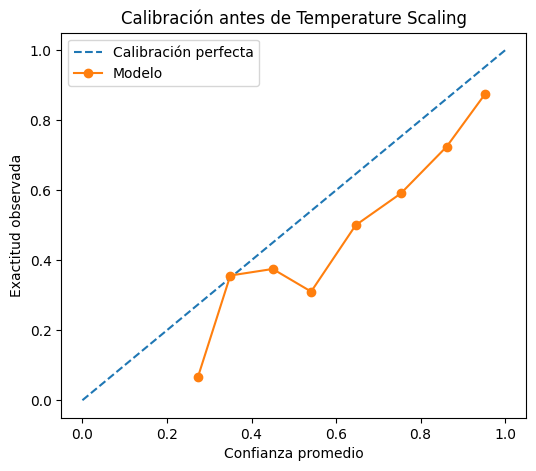

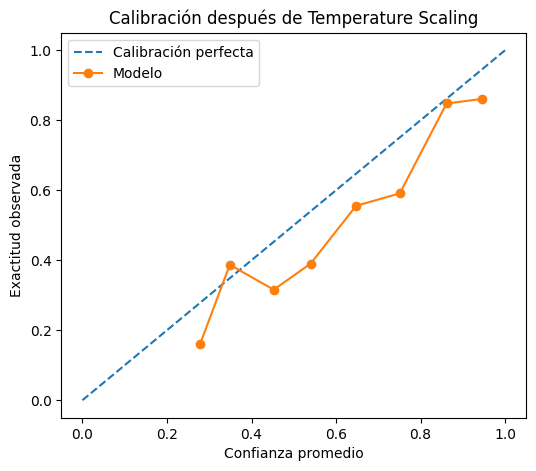

In [39]:
def plot_reliability(y_true, probs, n_bins=10, title="Reliability diagram"):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correct = (predictions == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_accs = []

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (
                (confidences >= lo) &
                (confidences <= hi)
            )
        else:
            mask = (
                (confidences >= lo) &
                (confidences < hi)
            )

        if np.any(mask):
            bin_centers.append(
                confidences[mask].mean()
            )
            bin_accs.append(
                correct[mask].mean()
            )

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "--", label="Calibración perfecta")
    plt.plot(bin_centers, bin_accs, marker="o", label="Modelo")
    plt.xlabel("Confianza promedio")
    plt.ylabel("Exactitud observada")
    plt.title(title)
    plt.legend()
    plt.show()

plot_reliability(
    y_test,
    probs_before,
    title="Calibración antes de Temperature Scaling"
)

plot_reliability(
    y_test,
    probs_after,
    title="Calibración después de Temperature Scaling"
)

Antes de aplicar Temperature Scaling, la curva del modelo se encuentra en varios puntos por debajo de la línea de calibración perfecta, lo que indica que sus probabilidades no estaban completamente bien calibradas. Después del ajuste, la curva se acerca un poco más a la diagonal en varios niveles de confianza, especialmente en los valores altos. Esto sugiere que el Temperature Scaling mejoró parcialmente la calibración de las probabilidades, aunque todavía persisten algunas diferencias entre la confianza estimada por el modelo y la exactitud realmente observada.

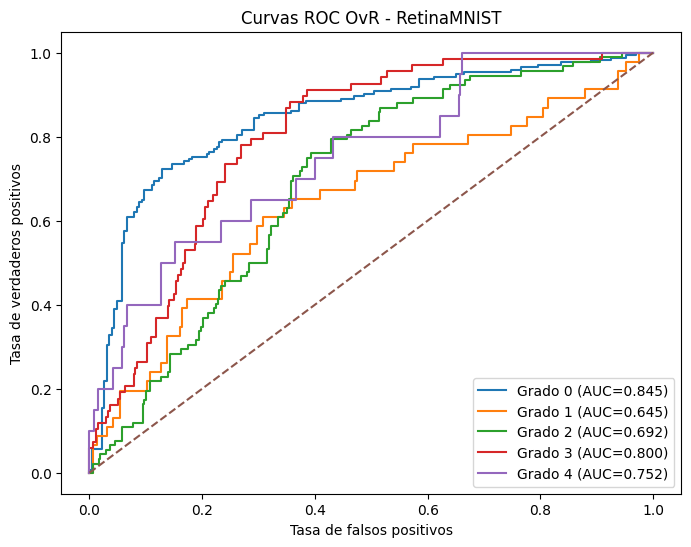

In [40]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(8, 6))

for c in range(num_classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, c],
        probs_after[:, c]
    )
    class_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[c]} (AUC={class_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC OvR - RetinaMNIST")
plt.legend()
plt.show()

Las curvas ROC muestran que el modelo tiene una capacidad de discriminación diferente según el grado. El mejor rendimiento se observa en el Grado 0 (AUC = 0.845) y en el Grado 3 (AUC = 0.800), mientras que el Grado 1 presenta el menor desempeño (AUC = 0.645). Los Grados 2 y 4 alcanzan valores intermedios. En general, todas las curvas se encuentran por encima de la línea diagonal de referencia, lo que indica que el modelo discrimina mejor que una clasificación aleatoria, aunque su desempeño varía entre las clases.

## 12. Conclusiones del laboratorio

Con esta adaptación:
- El dataset cambió de PneumoniaMNIST a **RetinaMNIST**.
- La entrada pasó de 1 canal a **3 canales RGB**.
- La salida pasó de clasificación binaria a **5 clases ordinales**.
- Se modificaron las métricas para el escenario multiclase.
- Se añadió **Kappa cuadrático** para considerar el orden de los grados.
- Se adaptó ResNet18 sin repetir canales.
- Se implementaron los cinco ejercicios propuestos.
- Se agregó calibración por **Temperature Scaling** y curvas ROC multiclase OvR.

Para una comparación formal, conviene repetir los experimentos con varias semillas y reportar media ± desviación estándar.